In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# Load the Iris dataset
df = pd.read_csv("Iris.csv")

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Shuffle the dataset to remove any ordering bias before splitting
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_shuffled.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,74,6.1,2.8,4.7,1.2,Iris-versicolor
1,19,5.7,3.8,1.7,0.3,Iris-setosa
2,119,7.7,2.6,6.9,2.3,Iris-virginica
3,79,6.0,2.9,4.5,1.5,Iris-versicolor
4,77,6.8,2.8,4.8,1.4,Iris-versicolor


In [6]:
df_shuffled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# Drop the Id column; features are the 4 flower measurements
X = df_shuffled[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df_shuffled['Species']

In [8]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,6.1,2.8,4.7,1.2
1,5.7,3.8,1.7,0.3
2,7.7,2.6,6.9,2.3
3,6.0,2.9,4.5,1.5
4,6.8,2.8,4.8,1.4
...,...,...,...,...
145,6.1,2.8,4.0,1.3
146,4.9,2.5,4.5,1.7
147,5.8,4.0,1.2,0.2
148,5.8,2.6,4.0,1.2


In [9]:
y

0      Iris-versicolor
1          Iris-setosa
2       Iris-virginica
3      Iris-versicolor
4      Iris-versicolor
            ...       
145    Iris-versicolor
146     Iris-virginica
147        Iris-setosa
148    Iris-versicolor
149     Iris-virginica
Name: Species, Length: 150, dtype: object

In [10]:
# SVM is sensitive to feature scale; StandardScaler normalises each feature to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Split 70/30, fit an RBF-kernel SVM — the default kernel; works well for this dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
y_pred

array(['Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica'], dtype=object)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9777777777777777

Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      1.00      0.97        15
 Iris-virginica       1.00      0.93      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



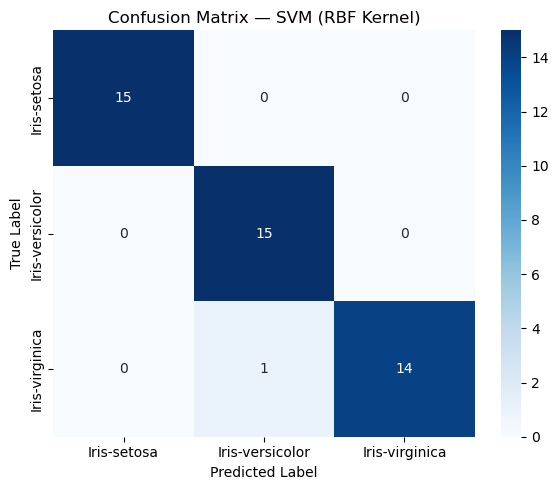

In [14]:
# Heatmap makes the confusion matrix easier to read than raw numbers
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title("Confusion Matrix — SVM (RBF Kernel)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Kernel Accuracy Comparison:
  linear    : 97.78%
  rbf       : 97.78%
  poly      : 88.89%
  sigmoid   : 88.89%


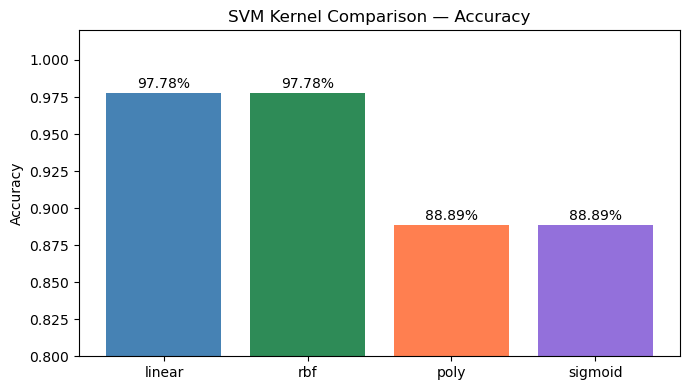

In [15]:
# Compare accuracy across all four standard SVM kernels
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = {}

for k in kernels:
    clf = SVC(kernel=k, C=1.0, gamma='scale', decision_function_shape='ovr')
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    results[k] = round(acc, 4)

print("Kernel Accuracy Comparison:")
for k, acc in results.items():
    print(f"  {k:<10}: {acc:.2%}")

plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(), color=['steelblue', 'seagreen', 'coral', 'mediumpurple'])
plt.title("SVM Kernel Comparison — Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.02)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.003, f"{v:.2%}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()